# 03 — ¿Se puede predecir el PM2.5 de mañana?

Los dos notebooks anteriores describieron el pasado: cómo se mueve la contaminación y qué papel juega el clima. Este intenta algo distinto: anticipar el PM2.5 medio del día siguiente en cada estación, usando solo información disponible hoy.

La regla de oro aquí es compararse contra una línea base ingenua antes de celebrar nada. En series con tanta inercia como esta, decir "mañana estará igual que hoy" (persistencia) ya acierta bastante, y cualquier modelo que no la supere con claridad no aporta. Los tres enfoques que se comparan:

- **Persistencia**: mañana = hoy. Cero aprendizaje, referencia obligatoria.
- **Regresión lineal**: combinación lineal de la historia reciente, el clima de mañana y el calendario.
- **Random forest**: mismo insumo, pero capaz de capturar relaciones no lineales.

Las features de clima usan el valor de *mañana* (temperatura, humedad, viento, lluvia). No es trampa: en un uso real ese dato vendría del pronóstico meteorológico, que para el día siguiente es muy confiable. La lógica vive en `src/prediccion.py`; el notebook la importa y narra los resultados.

In [1]:
# cargar librerias e importar la logica de prediccion desde src
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from prediccion import (
    FECHA_CORTE,
    cargar_combinado,
    construir_dataset_diario,
    construir_features,
    dividir_por_fecha,
    entrenar_y_evaluar,
    metricas_por_estacion,
)

# construir la tabla de modelado: un ejemplo por estacion y dia,
# con el pm2.5 de manana como objetivo
diaria = construir_dataset_diario(cargar_combinado())
tabla = construir_features(diaria)
print(f"{len(tabla):,} ejemplos, de {tabla['fecha'].min():%Y-%m-%d} a {tabla['fecha'].max():%Y-%m-%d}")
tabla.head()

13,982 ejemplos, de 2015-01-05 a 2024-05-30


,fecha,estacion,pm25_hoy,pm25_ayer,pm25_hace_2,pm25_media_7d,temperatura_c_manhana,humedad_rel_pct_manhana,viento_vel_kmh_manhana,precipitacion_mm_manhana,pm25_manhana,mes,dia_semana
0,2015-01-18,CAMPO_DE_MARTE,10.287500,13.258333,13.470833,12.517355,21.000000,79.500000,10.183333,0.2,10.473913,1,0
1,2015-01-19,CAMPO_DE_MARTE,10.473913,10.287500,13.258333,12.176781,20.787500,82.875000,9.045833,0.0,11.083333,1,1
2,2015-01-20,CAMPO_DE_MARTE,11.083333,10.473913,10.287500,12.020575,20.962500,83.166667,9.562500,2.2,9.100000,1,2
3,2015-01-21,CAMPO_DE_MARTE,9.100000,11.083333,10.473913,11.579503,21.025000,86.250000,8.820833,3.2,13.813043,1,3
4,2015-01-22,CAMPO_DE_MARTE,13.813043,9.100000,11.083333,11.640994,20.870833,89.333333,7.725000,3.4,12.383333,1,4


## 1. Validación temporal, nunca aleatoria

Un split aleatorio sería hacer trampa: pondría días de 2024 en el entrenamiento y días de 2016 en la prueba, y el modelo "vería el futuro". Con series de tiempo la única evaluación honesta es entrenar en el pasado y probar en un futuro que el modelo nunca tocó. Aquí la frontera es el 1 de enero de 2023: todo lo anterior entrena, 2023 y 2024 prueban.

Los hiperparámetros del random forest tampoco se eligieron mirando la prueba — se ajustaron con 2022 como validación interna del entrenamiento.

In [2]:
# dividir por fecha y entrenar los tres enfoques
entrenamiento, prueba = dividir_por_fecha(tabla)
print(f"entrenamiento: {len(entrenamiento):,} dias (antes de {FECHA_CORTE}); prueba: {len(prueba):,} dias")

metricas, predicciones, modelos = entrenar_y_evaluar(entrenamiento, prueba)
metricas.round(2)

entrenamiento: 11,537 dias (antes de 2023-01-01); prueba: 2,445 dias


,mae,rmse
persistencia,3.90,5.39
regresion lineal,3.63,4.98
random forest,3.57,4.92


## 2. Lectura de los resultados

El random forest gana, pero por poco: MAE de 3.57 µg/m³ contra 3.90 de la persistencia, una mejora de 8.5%. La regresión lineal queda casi pegada (3.63). Ese margen estrecho no es un fracaso, es la respuesta honesta: el PM2.5 diario tiene tanta inercia que el valor de hoy ya explica la mayor parte de mañana, y lo que queda por encima es en buena parte ruido de eventos locales (quemas, obras, tráfico inusual) que ningún dato de este proyecto observa.

La mejora, eso sí, es consistente: se repite en el RMSE (4.92 vs 5.39) y en casi todas las estaciones, como se ve abajo.

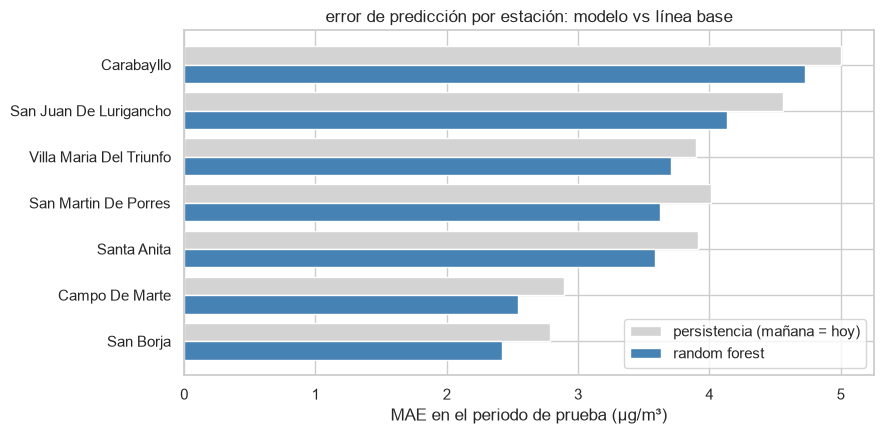

,dias,mae_persistencia,mae_lineal,mae_bosque
estacion,,,,
SAN_BORJA,383,2.79,2.59,2.42
CAMPO_DE_MARTE,229,2.90,2.96,2.54
SANTA_ANITA,477,3.92,3.64,3.58
SAN_MARTIN_DE_PORRES,323,4.01,3.70,3.62
VILLA_MARIA_DEL_TRIUNFO,387,3.90,3.54,3.70
SAN_JUAN_DE_LURIGANCHO,243,4.56,4.18,4.13
CARABAYLLO,403,5.00,4.72,4.73


In [3]:
# desglosar el mae por estacion y comparar persistencia vs random forest
por_estacion = metricas_por_estacion(predicciones).sort_values("mae_bosque")

fig, eje = plt.subplots(figsize=(9, 4.5))
posiciones = range(len(por_estacion))
eje.barh([p + 0.2 for p in posiciones], por_estacion["mae_persistencia"], height=0.4,
         label="persistencia (mañana = hoy)", color="lightgray")
eje.barh([p - 0.2 for p in posiciones], por_estacion["mae_bosque"], height=0.4,
         label="random forest", color="steelblue")
eje.set_yticks(list(posiciones))
eje.set_yticklabels([e.replace("_", " ").title() for e in por_estacion.index])
eje.set_xlabel("MAE en el periodo de prueba (µg/m³)")
eje.set_title("error de predicción por estación: modelo vs línea base")
eje.legend()
plt.tight_layout()
plt.show()

por_estacion.round(2)

El modelo ayuda más donde la persistencia sufre (Carabayllo, San Juan de Lurigancho, las estaciones más volátiles) y en las tranquilas como San Borja o Campo de Marte reduce un error que ya era bajo. La única lectura incómoda: en ninguna estación la mejora pasa de ~12%, así que nadie debería vender esto como un pronóstico preciso — es una referencia razonable con incertidumbre conocida.

## 3. Predicción contra realidad

Ver la serie completa vale más que cualquier métrica. Abajo, Santa Anita (la estación con más días de prueba) durante 2023: la predicción sigue bien el nivel y la estacionalidad, y se queda corta justo donde era esperable — los picos bruscos que ni la historia ni el clima anunciaban.

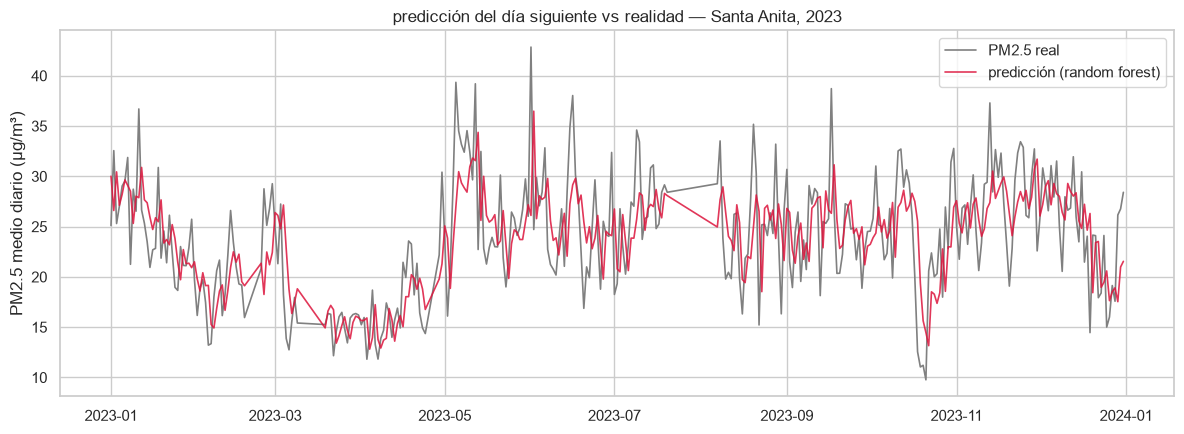

In [4]:
# graficar prediccion vs realidad en la estacion con mas dias de prueba
estacion_muestra = "SANTA_ANITA"
muestra = predicciones[
    (predicciones["estacion"] == estacion_muestra)
    & (predicciones["fecha"] < "2024-01-01")
].sort_values("fecha")

fig, eje = plt.subplots(figsize=(12, 4.5))
eje.plot(muestra["fecha"], muestra["pm25_manhana"], label="PM2.5 real", color="gray", linewidth=1.2)
eje.plot(muestra["fecha"], muestra["pred_bosque"], label="predicción (random forest)",
         color="crimson", linewidth=1.2, alpha=0.85)
eje.set_ylabel("PM2.5 medio diario (µg/m³)")
eje.set_title(f"predicción del día siguiente vs realidad — {estacion_muestra.replace('_', ' ').title()}, 2023")
eje.legend()
plt.tight_layout()
plt.show()

## 4. Qué mira el modelo

Las importancias del random forest cuentan la misma historia desde otro ángulo: la media móvil de 7 días y el valor de hoy concentran más del 80% del peso. El clima de mañana aporta poco pero no nada — viento y temperatura aparecen antes que cualquier variable de calendario, coherente con el papel de la ventilación que mostró el notebook 02.

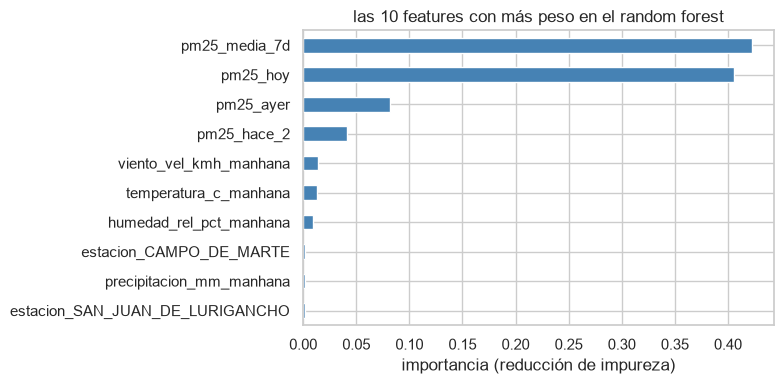

In [5]:
# ver las features mas importantes del random forest
importancias = (
    pd.Series(modelos["bosque"].feature_importances_, index=modelos["columnas"])
    .sort_values(ascending=False)
    .head(10)
)

fig, eje = plt.subplots(figsize=(8, 4))
importancias.iloc[::-1].plot.barh(ax=eje, color="steelblue")
eje.set_xlabel("importancia (reducción de impureza)")
eje.set_title("las 10 features con más peso en el random forest")
plt.tight_layout()
plt.show()

## Conclusiones y límites

Sí se puede predecir el PM2.5 de mañana, con matices. Un random forest con historia reciente, clima del día siguiente y calendario baja el error medio de 3.90 a 3.57 µg/m³ (−8.5% frente a la persistencia), de forma consistente entre estaciones y métricas. La lección metodológica importa más que la cifra: sin la línea base, un MAE de 3.57 sonaría impresionante; contra ella, se ve como lo que es — una mejora modesta sobre un problema dominado por la inercia.

Límites que conviene decir en voz alta:

- La serie termina en mayo de 2024, así que esto es un ejercicio retrospectivo, no un servicio de pronóstico en vivo.
- El clima "de mañana" es el observado por ERA5, no un pronóstico real; en producción el error del pronóstico meteorológico se sumaría al del modelo.
- Un solo modelo para las 7 estaciones: con más datos valdría probar modelos por estación o features de estaciones vecinas.

El dashboard incluye una pestaña de predicción con estas métricas y la comparación gráfica por estación.